# ETL Pipeline — Data Warehouse Cuaca Kebumen
**Star Schema: 3 Dimensi + 1 Fact Table → SQLite**

```
CSV (source)
    ↓
[EXTRACT]   → load raw data
    ↓
[TRANSFORM] → cleaning + derive kolom + mapping FK
    ↓
[LOAD]      → simpan ke star_schema.db (SQLite)
    ↓
[VALIDATE]  → cek integritas FK + sample query
```

## Sekilas tentang Proyek

Bagian ini menjelaskan struktur umum pipeline ETL yang akan kita bangun, mulai dari sumber data hingga validasi akhir.

## Setup

### Setup & Instalasi Library

Instalasi library yang dibutuhkan dan inisialisasi variabel global.

In [105]:
import csv
import sqlite3
import pandas as pd
from sqlalchemy import create_engine, text
from datetime import datetime

CSV_PATH = '/content/Daily_Cuaca_Kebumen.csv'
DB_PATH  = 'star_schema.db'

def query(sql):
    conn = sqlite3.connect(DB_PATH)
    df   = pd.read_sql(sql, conn)
    conn.close()
    return df

print('Setup selesai ')

Setup selesai 


### Inisialisasi Environment

---
## PERANCANGAN DATA WAREHOUSE

Bagian ini menjelaskan desain Data Warehouse yang digunakan untuk menyimpan
dan mengorganisasi data cuaca harian Kebumen dalam struktur yang optimal
untuk analisis multidimensional.

> **Catatan:** Desain ini disajikan di awal agar pipeline ETL yang dibangun
> di bawah mengacu pada skema yang sudah terencana, bukan sebaliknya.

### 3.1 Justifikasi Pemilihan Star Schema

Data Warehouse ini menggunakan pendekatan **Star Schema** dengan pertimbangan sebagai berikut:

| Aspek | Star Schema | Alternatif (Snowflake / Flat Table) |
|-------|-------------|--------------------------------------|
| **Kesederhanaan query** | Query cukup dengan 1–2 JOIN | Snowflake butuh JOIN berlapis |
| **Performa analisis** | Lebih cepat untuk agregasi | Flat table tidak terstruktur |
| **Skalabilitas** | Mudah ditambah dimensi baru | Flat table sulit diperluas |
| **Kecocokan data** | Cocok untuk data time-series harian | — |

Dengan dimensi waktu, lokasi, dan kondisi cuaca yang relatif stabil, Star Schema adalah
pilihan paling efisien dan mudah dipahami untuk kebutuhan analisis cuaca historis ini.

### 3.2 Diagram Star Schema (ERD)

Berikut adalah struktur relasi tabel dalam Data Warehouse:

```
                    ┌─────────────────────┐
                    │     dim_waktu        │
                    │─────────────────────│
                    │ PK  date_id          │
                    │     datetime         │
                    │     hari             │
                    │     nama_hari        │
                    │     tanggal          │
                    │     bulan            │
                    │     nama_bulan       │
                    │     kuartal          │
                    │     tahun            │
                    │     musim            │
                    │     sunrise          │
                    │     sunset           │
                    │     durasi_siang_... │
                    └──────────┬──────────┘
                               │ FK: date_id
┌────────────────┐             │             ┌──────────────────────┐
│   dim_lokasi   │             ▼             │  dim_kondisi_cuaca   │
│────────────────│   ┌──────────────────┐   │──────────────────────│
│ PK lokasi_id   │   │ fact_cuaca_harian │   │ PK kondisi_id        │
│    nama_lokasi │◄──│──────────────────│──►│    conditions        │
│    nama_stasiun│   │ PK fact_id       │   └──────────────────────┘
│    kabupaten   │   │ FK date_id       │
│    provinsi    │   │ FK lokasi_id     │
│    pulau       │   │ FK kondisi_id    │
│    latitude    │   │ ── MEASURES ──   │
│    longitude   │   │    tempmax       │
│    elevasi_mdpl│   │    tempmin       │
│    sumber_data │   │    temp          │
└────────────────┘   │    feelslikemax  │
                     │    feelslikemin  │
                     │    feelslike     │
                     │    dew           │
                     │    humidity      │
                     │    precip        │
                     │    precipprob    │
                     │    precipcover   │
                     │    windspeed     │
                     │    winddir       │
                     │    sealevel...   │
                     │    cloudcover    │
                     │    visibility    │
                     └──────────────────┘
```

### 3.3 Kamus Data Tabel

#### dim_waktu
| Kolom | Tipe | Keterangan |
|-------|------|------------|
| `date_id` | INTEGER | Primary Key, ID unik per tanggal |
| `datetime` | DATETIME | Tanggal observasi |
| `hari` | INTEGER | Hari dalam minggu (1=Senin, 7=Minggu) |
| `nama_hari` | TEXT | Nama hari (Monday–Sunday) |
| `tanggal` | INTEGER | Tanggal dalam bulan (1–31) |
| `bulan` | INTEGER | Bulan (1–12) |
| `nama_bulan` | TEXT | Nama bulan (January–December) |
| `kuartal` | INTEGER | Kuartal (1–4) |
| `tahun` | INTEGER | Tahun (1978–2022) |
| `musim` | TEXT | Musim: Hujan (Okt–Mar) / Kemarau (Apr–Sep) |
| `sunrise` | TEXT | Waktu matahari terbit (HH:MM) |
| `sunset` | TEXT | Waktu matahari terbenam (HH:MM) |
| `durasi_siang_menit` | FLOAT | Durasi siang hari dalam menit |

#### dim_lokasi
| Kolom | Tipe | Keterangan |
|-------|------|------------|
| `lokasi_id` | INTEGER | Primary Key (nilai tunggal = 1) |
| `nama_lokasi` | TEXT | Nama lengkap lokasi |
| `nama_stasiun` | TEXT | Nama stasiun BMKG |
| `kabupaten` | TEXT | Kabupaten Kebumen |
| `provinsi` | TEXT | Jawa Tengah |
| `pulau` | TEXT | Jawa |
| `latitude` | FLOAT | Koordinat lintang (-7.6728) |
| `longitude` | FLOAT | Koordinat bujur (109.6453) |
| `elevasi_mdpl` | INTEGER | Ketinggian dari permukaan laut (15 m) |
| `sumber_data` | TEXT | Sumber: Kaggle / Visual Crossing |

#### dim_kondisi_cuaca *(diperluas)*
| Kolom | Tipe | Keterangan |
|-------|------|------------|
| `kondisi_id` | INTEGER | Primary Key |
| `conditions` | TEXT | Deskripsi kondisi cuaca (kategorik unik) |
| `kategori_hujan` | TEXT | Klasifikasi: Hujan / Berawan / Cerah / Campuran |
| `tingkat_ekstrem` | TEXT | Level: Tinggi / Sedang / Rendah |

#### fact_cuaca_harian
| Kolom | Tipe | Satuan | Keterangan |
|-------|------|--------|------------|
| `fact_id` | INTEGER | — | Primary Key |
| `date_id` | INTEGER | — | FK → dim_waktu |
| `lokasi_id` | INTEGER | — | FK → dim_lokasi |
| `kondisi_id` | INTEGER | — | FK → dim_kondisi_cuaca |
| `tempmax` | FLOAT | °C | Suhu maksimum harian |
| `tempmin` | FLOAT | °C | Suhu minimum harian |
| `temp` | FLOAT | °C | Suhu rata-rata harian |
| `feelslikemax` | FLOAT | °C | Suhu terasa maksimum |
| `feelslikemin` | FLOAT | °C | Suhu terasa minimum |
| `feelslike` | FLOAT | °C | Suhu terasa rata-rata |
| `dew` | FLOAT | °C | Titik embun |
| `humidity` | FLOAT | % | Kelembapan relatif |
| `precip` | FLOAT | mm | Curah hujan |
| `precipprob` | FLOAT | % | Probabilitas hujan |
| `precipcover` | FLOAT | % | Persentase waktu hujan |
| `windspeed` | FLOAT | km/h | Kecepatan angin |
| `winddir` | FLOAT | ° | Arah angin |
| `sealevelpressure` | FLOAT | hPa | Tekanan udara laut |
| `cloudcover` | FLOAT | % | Tutupan awan |
| `visibility` | FLOAT | km | Jarak pandang |

---
## DATA UNDERSTANDING
Bagian ini menjelaskan pemahaman awal terhadap dataset sebelum dilakukan proses ETL.
Tahapan meliputi: deskripsi dataset, penjelasan variabel, statistik deskriptif,
analisis distribusi, dan identifikasi outlier.

### 2.1 Deskripsi Dataset

Dataset **Cuaca Harian Kebumen (1978–2022)** diperoleh dari platform Kaggle
([jerismeteo/cuaca-harian-kebumen-1978-2022](https://www.kaggle.com/datasets/jerismeteo/cuaca-harian-kebumen-1978-2022)),
yang bersumber dari rekaman observasi BMKG (Badan Meteorologi, Klimatologi, dan Geofisika)
Stasiun Klimatologi Kebumen, Jawa Tengah.

Dataset ini mencakup data observasi harian selama lebih dari **4 dekade (1978–2022)**
dengan variabel meteorologi seperti suhu udara, kelembapan, curah hujan, kecepatan angin,
tekanan udara, dan kondisi cuaca.

In [106]:
df_raw = pd.read_csv(CSV_PATH, encoding='latin1', on_bad_lines='skip')

print("=" * 55)
print("  INFORMASI DASAR DATASET")
print("=" * 55)
print(f"  Jumlah baris   : {df_raw.shape[0]:,} record")
print(f"  Jumlah kolom   : {df_raw.shape[1]} variabel")

df_raw['datetime'] = pd.to_datetime(df_raw['datetime'], errors='coerce')
tgl_min = df_raw['datetime'].min().strftime('%d %B %Y')
tgl_max = df_raw['datetime'].max().strftime('%d %B %Y')
print(f"  Periode data   : {tgl_min}  →  {tgl_max}")
print(f"  Sumber         : BMKG via Kaggle (jerismeteo)")
print(f"  Lokasi         : Kebumen, Jawa Tengah, Indonesia")
print(f"  Koordinat      : 7.67°S, 109.65°E | Elevasi ±15 mdpl")
print("=" * 55)
df_raw.head(5)

  INFORMASI DASAR DATASET
  Jumlah baris   : 16,390 record
  Jumlah kolom   : 33 variabel
  Periode data   : 16 February 1978  →  31 December 2022
  Sumber         : BMKG via Kaggle (jerismeteo)
  Lokasi         : Kebumen, Jawa Tengah, Indonesia
  Koordinat      : 7.67°S, 109.65°E | Elevasi ±15 mdpl


/tmp/ipykernel_619/307935692.py:1: DtypeWarning:

Columns (26,27) have mixed types. Specify dtype option on import or set low_memory=False.



,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,"Kebumen, Indonesia",1978-02-16,32.1,25.1,28.1,39.3,25.1,31.4,24.8,83.5,...,NaN,NaN,NaN,1978-02-16T05:45:06,1978-02-16T18:05:40,0.28,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,96805099999
1,"Kebumen, Indonesia",1978-02-17,31.1,25.1,27.9,37.9,25.1,31.8,24.9,84.4,...,NaN,NaN,NaN,1978-02-17T05:45:14,1978-02-17T18:05:24,0.31,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,96805099999
2,"Kebumen, Indonesia",1978-02-18,32.1,26.1,29.0,40.8,26.1,33.6,25.5,82.7,...,NaN,NaN,NaN,1978-02-18T05:45:22,1978-02-18T18:05:08,0.34,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,96805099999
3,"Kebumen, Indonesia",1978-02-19,33.1,25.1,28.5,39.4,25.1,32.2,25.1,83.2,...,NaN,NaN,NaN,1978-02-19T05:45:29,1978-02-19T18:04:50,0.38,Overcast,Cloudy skies throughout the day.,cloudy,96805099999
4,"Kebumen, Indonesia",1978-02-20,31.1,24.1,27.1,44.4,24.1,30.7,23.1,85.2,...,NaN,NaN,NaN,1978-02-20T05:45:35,1978-02-20T18:04:32,0.41,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,96805099999


### 2.2 Kamus Data (Data Dictionary)

Berikut adalah penjelasan setiap variabel yang terdapat dalam dataset:

| No | Nama Kolom | Tipe Data | Satuan | Keterangan |
|----|-----------|-----------|--------|------------|
| 1 | `datetime` | datetime | — | Tanggal observasi harian |
| 2 | `tempmax` | float | °C | Suhu udara maksimum harian |
| 3 | `tempmin` | float | °C | Suhu udara minimum harian |
| 4 | `temp` | float | °C | Suhu udara rata-rata harian |
| 5 | `feelslikemax` | float | °C | Suhu yang dirasakan (maks) |
| 6 | `feelslikemin` | float | °C | Suhu yang dirasakan (min) |
| 7 | `feelslike` | float | °C | Suhu yang dirasakan (rata-rata) |
| 8 | `dew` | float | °C | Titik embun (dew point) |
| 9 | `humidity` | float | % | Kelembapan udara relatif |
| 10 | `precip` | float | mm | Jumlah curah hujan harian |
| 11 | `precipprob` | float | % | Probabilitas terjadinya hujan |
| 12 | `precipcover` | float | % | Persentase waktu hujan dalam sehari |
| 13 | `windspeed` | float | km/h | Kecepatan angin rata-rata |
| 14 | `winddir` | float | ° | Arah angin (0–360°) |
| 15 | `sealevelpressure` | float | hPa | Tekanan udara permukaan laut |
| 16 | `cloudcover` | float | % | Persentase tutupan awan |
| 17 | `visibility` | float | km | Jarak pandang horizontal |
| 18 | `sunrise` | object | HH:MM | Waktu matahari terbit |
| 19 | `sunset` | object | HH:MM | Waktu matahari terbenam |
| 20 | `conditions` | object | — | Deskripsi kondisi cuaca (kategorik) |

In [107]:
print("── Tipe Data Kolom ──")
print(df_raw.dtypes)

missing  = df_raw.isnull().sum()
miss_pct = (missing / len(df_raw) * 100).round(2)
miss_df  = pd.DataFrame({'Jumlah Missing': missing, 'Persen (%)': miss_pct})
miss_df  = miss_df[miss_df['Jumlah Missing'] > 0].sort_values('Persen (%)', ascending=False)

print(f"\n── Ringkasan Missing Values (hanya kolom bermasalah) ──")
print(miss_df.to_string())
print(f"\nTotal kolom dengan missing : {len(miss_df)} dari {df_raw.shape[1]} kolom")

── Tipe Data Kolom ──
name                        object
datetime            datetime64[ns]
tempmax                    float64
tempmin                    float64
temp                       float64
feelslikemax               float64
feelslikemin               float64
feelslike                  float64
dew                        float64
humidity                   float64
precip                     float64
precipprob                 float64
precipcover                float64
preciptype                  object
snow                       float64
snowdepth                  float64
windgust                   float64
windspeed                  float64
winddir                    float64
sealevelpressure           float64
cloudcover                 float64
visibility                 float64
solarradiation             float64
solarenergy                float64
uvindex                    float64
severerisk                 float64
sunrise                     object
sunset                      objec

### 2.3 Statistik Deskriptif

In [108]:
numeric_cols = ['tempmax','tempmin','temp','humidity',
                'precip','windspeed','sealevelpressure',
                'cloudcover','visibility','dew']
numeric_cols = [c for c in numeric_cols if c in df_raw.columns]

desc = df_raw[numeric_cols].describe().T
desc.columns = ['N','Mean','Std','Min','Q1','Median','Q3','Max']
desc = desc.round(2)

print("── Statistik Deskriptif Variabel Utama ──")
print(desc.to_string())

── Statistik Deskriptif Variabel Utama ──
                        N     Mean    Std    Min      Q1  Median      Q3     Max
tempmax           15969.0    29.93   1.71   21.9    28.9    30.1    31.2    55.7
tempmin           15969.0    24.77   1.34    2.6    24.1    24.9    25.4    33.7
temp              15969.0    27.08   1.22   20.4    26.3    27.2    27.9    36.0
humidity          15969.0    82.27   4.49   46.0    79.6    82.4    85.0    98.8
precip            15969.0     9.04  21.32    0.0     0.0     0.7     7.5   318.0
windspeed         16390.0    16.73   8.17    0.0    11.2    16.0    22.3   133.6
sealevelpressure  12362.0  1011.17   1.87  962.1  1010.0  1011.2  1012.4  1024.1
cloudcover        15969.0    72.59  16.33    0.0    62.0    75.0    85.0   100.0
visibility        15964.0    10.36   2.10    1.0     9.0    10.1    11.4    37.0
dew               15969.0    23.68   1.09    8.4    23.1    23.9    24.4    26.5


#### Interpretasi Statistik Deskriptif

Beberapa temuan awal dari statistik deskriptif:

- **Suhu udara** (`temp`) rata-rata sekitar **26–28 °C**, konsisten dengan iklim tropis Jawa Tengah. Rentang suhu harian (maks–min) sekitar 8–10 °C.
- **Kelembapan** (`humidity`) rata-rata tinggi (>70%), sesuai karakteristik wilayah pesisir selatan Jawa.
- **Curah hujan** (`precip`) memiliki distribusi sangat menjulur ke kanan (*right-skewed*), artinya sebagian besar hari tidak hujan, namun sesekali terjadi hujan sangat lebat.
- **Kecepatan angin** (`windspeed`) relatif rendah dengan variasi kecil, mencerminkan kondisi angin moderat khas dataran rendah pantai.
- **Tekanan udara** (`sealevelpressure`) stabil di sekitar 1010–1015 hPa, normal untuk wilayah tropis.

### 2.4 Distribusi Data

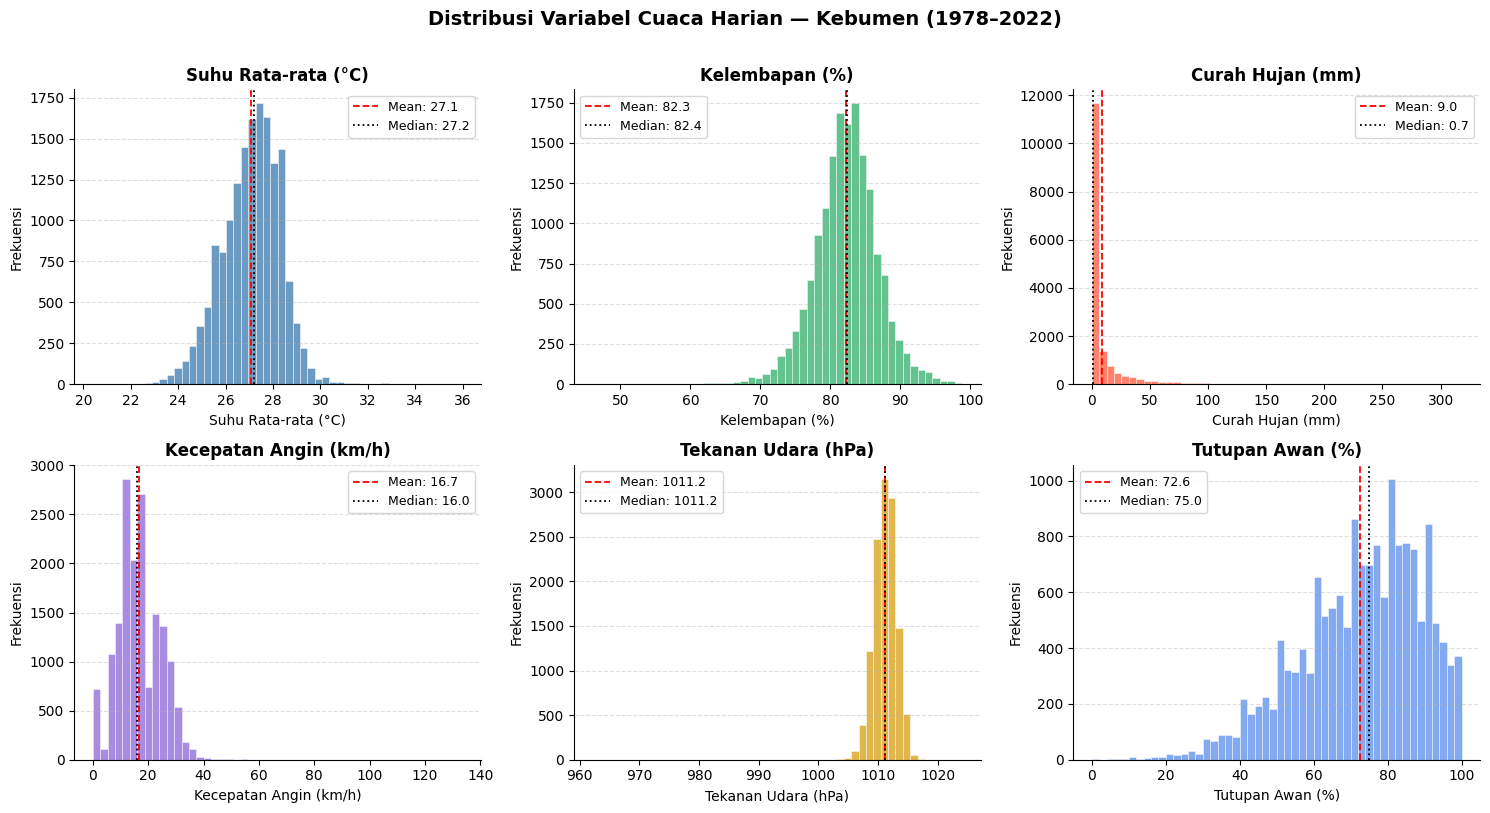

Histogram distribusi selesai


In [109]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

viz_cols = {
    'temp'            : 'Suhu Rata-rata (°C)',
    'humidity'        : 'Kelembapan (%)',
    'precip'          : 'Curah Hujan (mm)',
    'windspeed'       : 'Kecepatan Angin (km/h)',
    'sealevelpressure': 'Tekanan Udara (hPa)',
    'cloudcover'      : 'Tutupan Awan (%)'
}
viz_cols = {k: v for k, v in viz_cols.items() if k in df_raw.columns}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colors = ['steelblue','mediumseagreen','tomato','mediumpurple','goldenrod','cornflowerblue']

for i, (col, label) in enumerate(viz_cols.items()):
    data = df_raw[col].dropna()
    axes[i].hist(data, bins=50, color=colors[i], alpha=0.80, edgecolor='white', linewidth=0.4)

    mean_val   = data.mean()
    median_val = data.median()
    axes[i].axvline(mean_val,   color='red',   linestyle='--', linewidth=1.3, label=f'Mean: {mean_val:.1f}')
    axes[i].axvline(median_val, color='black', linestyle=':',  linewidth=1.3, label=f'Median: {median_val:.1f}')

    axes[i].set_title(label, fontsize=12, fontweight='bold')
    axes[i].set_xlabel(label, fontsize=10)
    axes[i].set_ylabel('Frekuensi', fontsize=10)
    axes[i].legend(fontsize=9)
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)
    sns.despine(ax=axes[i])

plt.suptitle('Distribusi Variabel Cuaca Harian — Kebumen (1978–2022)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('du_histogram_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Histogram distribusi selesai')

### 2.5 Identifikasi Outlier

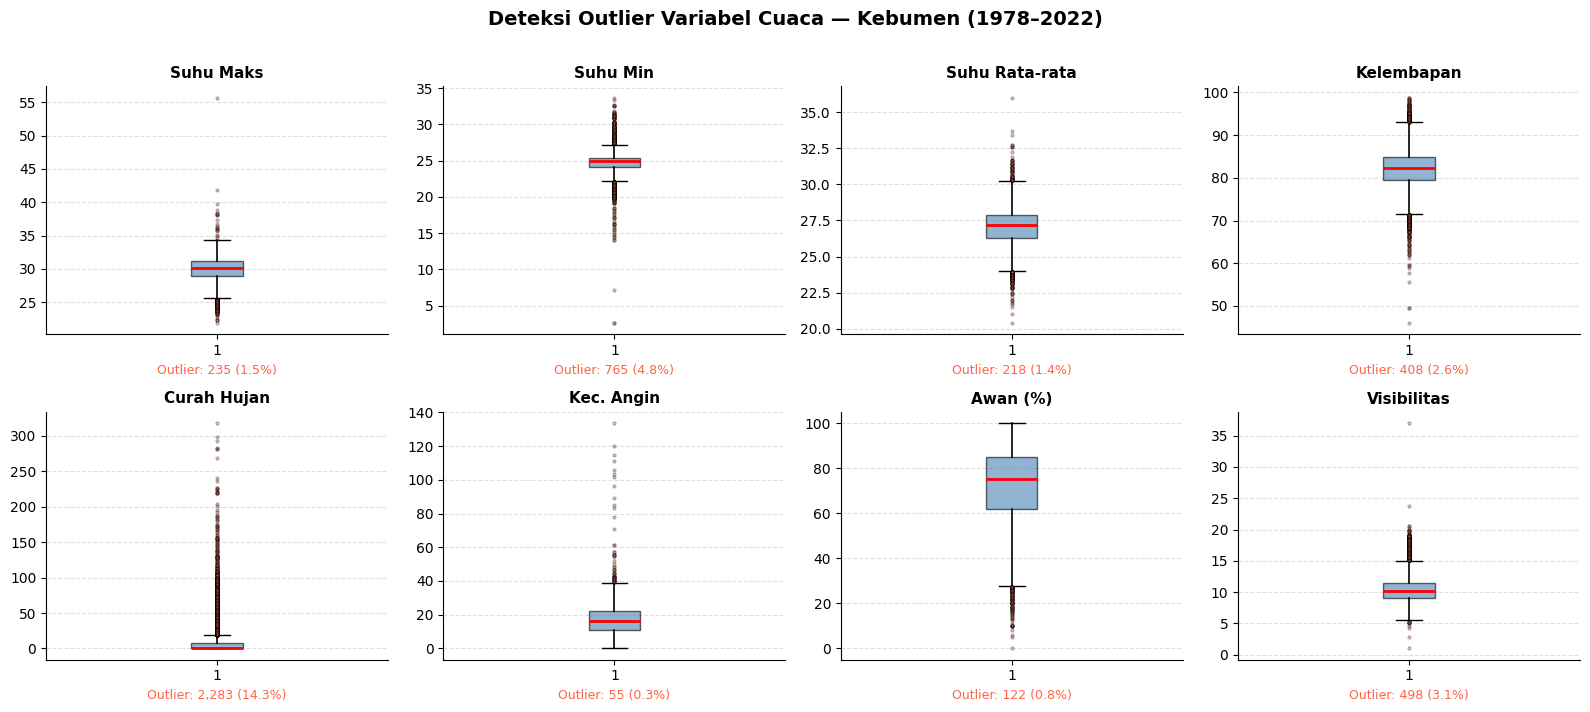

Boxplot outlier selesai


In [110]:
box_cols = ['tempmax','tempmin','temp','humidity',
            'precip','windspeed','cloudcover','visibility']
box_cols = [c for c in box_cols if c in df_raw.columns]
labels   = ['Suhu Maks','Suhu Min','Suhu Rata-rata',
            'Kelembapan','Curah Hujan','Kec. Angin','Awan (%)','Visibilitas']
labels   = labels[:len(box_cols)]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, (col, lbl) in enumerate(zip(box_cols, labels)):
    data = df_raw[col].dropna()
    axes[i].boxplot(data, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    flierprops=dict(marker='o', markersize=2,
                                    alpha=0.3, markerfacecolor='tomato'))
    axes[i].set_title(lbl, fontsize=11, fontweight='bold')
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)
    sns.despine(ax=axes[i])


    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR    = Q3 - Q1
    n_out  = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    axes[i].set_xlabel(f'Outlier: {n_out:,} ({n_out/len(data)*100:.1f}%)',
                       fontsize=9, color='tomato')

plt.suptitle('Deteksi Outlier Variabel Cuaca — Kebumen (1978–2022)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('du_boxplot_outlier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Boxplot outlier selesai')

#### Interpretasi Outlier

Berdasarkan metode **IQR (Interquartile Range)**, nilai dianggap outlier jika berada di luar rentang `[Q1 − 1.5×IQR, Q3 + 1.5×IQR]`.

**Temuan:**

- **Curah Hujan (`precip`)** memiliki outlier paling banyak. Hal ini wajar karena distribusinya memang *right-skewed* — hujan ekstrem sesekali terjadi namun frekuensinya rendah.
- **Suhu (`temp`, `tempmax`, `tempmin`)** memiliki outlier minimal, menandakan suhu di Kebumen relatif stabil sepanjang tahun.
- **Kelembapan dan Tutupan Awan** memiliki sebaran yang cukup normal dengan sedikit outlier.

> **Catatan:** Outlier pada data cuaca tidak selalu berarti *error* — bisa jadi merupakan kejadian cuaca ekstrem yang nyata (banjir, kemarau panjang). Penanganan dilakukan di tahap **Transform** dengan strategi imputasi, bukan penghapusan, agar rekaman historis tetap terjaga.

---
## EXTRACT
Load raw data dari CSV, tidak ada modifikasi apapun di tahap ini.

In [111]:
df_raw = pd.read_csv(CSV_PATH, encoding='latin1', on_bad_lines='skip')
print(f'Raw shape : {df_raw.shape}')
print(f'Kolom     : {list(df_raw.columns)}')
df_raw.head(3)

Raw shape : (16390, 33)
Kolom     : ['name', 'datetime', 'tempmax', 'tempmin', 'temp', 'feelslikemax', 'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'precipcover', 'preciptype', 'snow', 'snowdepth', 'windgust', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'sunrise', 'sunset', 'moonphase', 'conditions', 'description', 'icon', 'stations']


/tmp/ipykernel_619/3003038733.py:1: DtypeWarning:

Columns (26,27) have mixed types. Specify dtype option on import or set low_memory=False.



,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,"Kebumen, Indonesia",1978-02-16,32.1,25.1,28.1,39.3,25.1,31.4,24.8,83.5,...,NaN,NaN,NaN,1978-02-16T05:45:06,1978-02-16T18:05:40,0.28,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,96805099999
1,"Kebumen, Indonesia",1978-02-17,31.1,25.1,27.9,37.9,25.1,31.8,24.9,84.4,...,NaN,NaN,NaN,1978-02-17T05:45:14,1978-02-17T18:05:24,0.31,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,96805099999
2,"Kebumen, Indonesia",1978-02-18,32.1,26.1,29.0,40.8,26.1,33.6,25.5,82.7,...,NaN,NaN,NaN,1978-02-18T05:45:22,1978-02-18T18:05:08,0.34,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,96805099999


### Memuat Data Mentah dari CSV

Data cuaca harian dimuat langsung dari file CSV tanpa modifikasi awal.

In [112]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16390 entries, 0 to 16389
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              16390 non-null  object 
 1   datetime          16390 non-null  object 
 2   tempmax           15969 non-null  float64
 3   tempmin           15969 non-null  float64
 4   temp              15969 non-null  float64
 5   feelslikemax      15969 non-null  float64
 6   feelslikemin      15969 non-null  float64
 7   feelslike         15969 non-null  float64
 8   dew               15969 non-null  float64
 9   humidity          15969 non-null  float64
 10  precip            15969 non-null  float64
 11  precipprob        15969 non-null  float64
 12  precipcover       16390 non-null  float64
 13  preciptype        9119 non-null   object 
 14  snow              8358 non-null   float64
 15  snowdepth         8358 non-null   float64
 16  windgust          356 non-null    float6

### Memeriksa Tipe Data Awal

In [113]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({'Missing': missing, 'Persen (%)': missing_pct}).query('Missing > 0').sort_values('Persen (%)', ascending=False)

,Missing,Persen (%)
severerisk,16034,97.83
windgust,16034,97.83
solarenergy,11642,71.03
solarradiation,11642,71.03
uvindex,11642,71.03
snow,8032,49.01
snowdepth,8032,49.01
preciptype,7271,44.36
sealevelpressure,4028,24.58
winddir,714,4.36


### Ringkasan Missing Values Data Mentah

---
## TRANSFORM
Tahap ini dibagi menjadi:
1. Cleaning (drop kolom banyak null, isi null, hapus duplikat)
2. Cast tipe data
3. Derive kolom baru
4. Bangun tabel dimensi
5. Bangun fact table + mapping FK

### Justifikasi Keputusan Transformasi

Setiap langkah transformasi didasarkan pada pertimbangan berikut:

| Langkah | Keputusan | Alasan |
|---------|-----------|--------|
| **T1 — Drop kolom >40% null** | Threshold 40% | Kolom dengan lebih dari 40% nilai hilang dianggap tidak dapat diimputasi secara reliabel karena terlalu banyak informasi yang hilang. Di bawah threshold ini, imputasi masih representatif |
| **T2 — Cast datetime** | Dilakukan sebelum imputasi | Konversi tipe data harus dilakukan lebih awal agar operasi berbasis waktu (ffill, derive kolom) dapat berjalan dengan benar |
| **T3 — Hapus duplikat** | `drop_duplicates()` | Satu tanggal hanya boleh memiliki satu baris observasi. Duplikat dapat timbul dari proses scraping atau penggabungan data |
| **T4a — Imputasi hujan → 0** | Isi dengan 0 | Nilai null pada kolom `precip`, `precipprob`, dan `precipcover` diinterpretasikan sebagai **tidak ada hujan**, bukan data hilang. Dalam meteorologi, ketiadaan catatan hujan berarti tidak terjadi hujan pada hari tersebut |
| **T4b — Imputasi angin & numerik → median** | Median, bukan mean | Median lebih **robust terhadap outlier** dibanding mean. Data cuaca seperti kecepatan angin dan tekanan udara memiliki nilai ekstrem sesekali yang akan menarik mean ke arah yang tidak representatif |
| **T4c — Imputasi kategorik → modus** | Nilai terbanyak | Untuk kolom teks (`conditions`), tidak ada operasi aritmatika yang bisa dilakukan. Modus (kondisi cuaca paling sering muncul) adalah pilihan paling konservatif |
| **T4d — Imputasi datetime → ffill** | Forward fill | Tanggal yang hilang diisi dengan tanggal sebelumnya agar urutan kronologis tetap terjaga dan tidak muncul lompatan waktu yang merusak dimensi waktu |

In [114]:
threshold = 0.4
df = df_raw.loc[:, df_raw.isnull().mean() < threshold].copy()
print(f'Kolom dibuang (>40% null) : {df_raw.shape[1] - df.shape[1]}')
print(f'Kolom tersisa             : {df.shape[1]}')

df.columns = df.columns.str.replace('"', '').str.strip()
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

before_dedup = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Duplikat dihapus          : {before_dedup - len(df)} baris')

rain_cols = [c for c in ['precip', 'precipprob', 'precipcover'] if c in df.columns]
for col in rain_cols:
    df[col] = df[col].fillna(0)

wind_cols = [c for c in ['winddir', 'windspeed'] if c in df.columns]
for col in wind_cols:
    df[col] = df[col].fillna(df[col].median())

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
skip = set(rain_cols + wind_cols)
for col in numeric_cols:
    if col not in skip:
        df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df['datetime'] = df['datetime'].ffill()

sisa = df.isnull().sum().sum()
print(f'\nSisa missing values : {sisa}')
print('Semua bersih ✓' if sisa == 0 else '⚠ Masih ada null:')
if sisa > 0:
    print(df.isnull().sum()[df.isnull().sum() > 0])

/tmp/ipykernel_619/3462500315.py:29: UserWarning:

Unable to sort modes: '<' not supported between instances of 'int' and 'str'



Kolom dibuang (>40% null) : 8
Kolom tersisa             : 25
Duplikat dihapus          : 0 baris

Sisa missing values : 0
Semua bersih ✓


### Transformasi Data: Cleaning & Imputasi

Langkah-langkah pembersihan data meliputi penghapusan kolom dengan banyak missing value, penanganan duplikat, dan imputasi nilai yang hilang.

In [115]:
print(df.columns.tolist())

['name', 'datetime', 'tempmax', 'tempmin', 'temp', 'feelslikemax', 'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'precipcover', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'sunrise', 'sunset', 'moonphase', 'conditions', 'description', 'icon', 'stations']


### Kolom Tersisa Setelah Cleaning

In [116]:
total_missing = df.isnull().sum().sum()
print(f"Total missing values : {total_missing}")
print("Semua bersih " if total_missing == 0 else "Masih ada missing values!\n")

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing': missing,
    'Persen (%)': missing_pct
}).query('Missing > 0').sort_values('Persen (%)', ascending=False)

if len(missing_df) > 0:
    print("Kolom yang masih ada missing:")
    print(missing_df)
else:
    print("Tidak ada kolom dengan missing values")

print("\n── Cek per tipe data ──")
print("Numerik :")
print(df.select_dtypes(include=['float64','int64']).isnull().sum()[
    df.select_dtypes(include=['float64','int64']).isnull().sum() > 0
])
print("\nKategorik :")
print(df.select_dtypes(include='object').isnull().sum()[
    df.select_dtypes(include='object').isnull().sum() > 0
])
print("\nDatetime :")
print(df.select_dtypes(include='datetime').isnull().sum()[
    df.select_dtypes(include='datetime').isnull().sum() > 0
])

Total missing values : 0
Semua bersih 
Tidak ada kolom dengan missing values

── Cek per tipe data ──
Numerik :
Series([], dtype: int64)

Kategorik :
Series([], dtype: int64)

Datetime :
Series([], dtype: int64)


### Validasi Akhir Missing Values

Memastikan tidak ada lagi nilai `null` setelah proses cleaning dan imputasi.

In [117]:

df['hari']       = df['datetime'].dt.dayofweek + 1
df['nama_hari']  = df['datetime'].dt.day_name()
df['tanggal']    = df['datetime'].dt.day
df['bulan']      = df['datetime'].dt.month
df['nama_bulan'] = df['datetime'].dt.month_name()
df['kuartal']    = df['datetime'].dt.quarter
df['tahun']      = df['datetime'].dt.year
df['musim']      = df['bulan'].map(
    lambda m: 'Hujan' if m in [10, 11, 12, 1, 2, 3] else 'Kemarau'
)

if 'sunrise' in df.columns and 'sunset' in df.columns:
    def parse_time(t):
        try:
            return pd.to_datetime(t, format='%H:%M:%S', errors='coerce')
        except:
            return pd.NaT

    sr = pd.to_datetime(df['sunrise'], errors='coerce')
    ss = pd.to_datetime(df['sunset'],  errors='coerce')
    df['durasi_siang_menit'] = (ss - sr).dt.total_seconds() / 60

print('Kolom derive berhasil dibuat')
df[['datetime','hari','nama_hari','bulan','nama_bulan','kuartal','tahun','musim']].head(30)

Kolom derive berhasil dibuat


,datetime,hari,nama_hari,bulan,nama_bulan,kuartal,tahun,musim
0,1978-02-16,4,Thursday,2,February,1,1978,Hujan
1,1978-02-17,5,Friday,2,February,1,1978,Hujan
2,1978-02-18,6,Saturday,2,February,1,1978,Hujan
3,1978-02-19,7,Sunday,2,February,1,1978,Hujan
4,1978-02-20,1,Monday,2,February,1,1978,Hujan
5,1978-02-21,2,Tuesday,2,February,1,1978,Hujan
6,1978-02-22,3,Wednesday,2,February,1,1978,Hujan
7,1978-02-23,4,Thursday,2,February,1,1978,Hujan
8,1978-02-24,5,Friday,2,February,1,1978,Hujan
9,1978-02-25,6,Saturday,2,February,1,1978,Hujan


### Derive Kolom Baru (Tanggal, Waktu, Musim)

Membuat kolom-kolom baru yang berguna dari kolom `datetime`, seperti hari, bulan, tahun, dan musim.

In [118]:

waktu_cols = ['datetime', 'hari', 'nama_hari', 'tanggal',
              'bulan', 'nama_bulan', 'kuartal', 'tahun', 'musim']

if 'sunrise' in df.columns:        waktu_cols.append('sunrise')
if 'sunset'  in df.columns:        waktu_cols.append('sunset')
if 'durasi_siang_menit' in df.columns: waktu_cols.append('durasi_siang_menit')

dim_waktu = (
    df[waktu_cols]
    .drop_duplicates(subset='datetime')
    .reset_index(drop=True)
)
dim_waktu.insert(0, 'date_id', range(1, len(dim_waktu) + 1))

print(f'dim_waktu : {dim_waktu.shape}')
dim_waktu.head(15)

dim_waktu : (16390, 13)


,date_id,datetime,hari,nama_hari,tanggal,bulan,nama_bulan,kuartal,tahun,musim,sunrise,sunset,durasi_siang_menit
0,1,1978-02-16,4,Thursday,16,2,February,1,1978,Hujan,1978-02-16T05:45:06,1978-02-16T18:05:40,740.566667
1,2,1978-02-17,5,Friday,17,2,February,1,1978,Hujan,1978-02-17T05:45:14,1978-02-17T18:05:24,740.166667
2,3,1978-02-18,6,Saturday,18,2,February,1,1978,Hujan,1978-02-18T05:45:22,1978-02-18T18:05:08,739.766667
3,4,1978-02-19,7,Sunday,19,2,February,1,1978,Hujan,1978-02-19T05:45:29,1978-02-19T18:04:50,739.350000
4,5,1978-02-20,1,Monday,20,2,February,1,1978,Hujan,1978-02-20T05:45:35,1978-02-20T18:04:32,738.950000
5,6,1978-02-21,2,Tuesday,21,2,February,1,1978,Hujan,1978-02-21T05:45:41,1978-02-21T18:04:13,738.533333
6,7,1978-02-22,3,Wednesday,22,2,February,1,1978,Hujan,1978-02-22T05:45:46,1978-02-22T18:03:53,738.116667
7,8,1978-02-23,4,Thursday,23,2,February,1,1978,Hujan,1978-02-23T05:45:50,1978-02-23T18:03:33,737.716667
8,9,1978-02-24,5,Friday,24,2,February,1,1978,Hujan,1978-02-24T05:45:54,1978-02-24T18:03:12,737.300000
9,10,1978-02-25,6,Saturday,25,2,February,1,1978,Hujan,1978-02-25T05:45:58,1978-02-25T18:02:51,736.883333


### Membangun Dimensi Waktu (`dim_waktu`)

Membuat tabel dimensi yang berisi informasi waktu.

In [119]:

dim_lokasi = pd.DataFrame([{
    'lokasi_id'    : 1,
    'nama_lokasi'  : 'Kebumen, Indonesia',
    'nama_stasiun' : 'Stasiun Klimatologi Kebumen',
    'kabupaten'    : 'Kebumen',
    'provinsi'     : 'Jawa Tengah',
    'pulau'        : 'Jawa',
    'latitude'     : -7.6728,
    'longitude'    : 109.6453,
    'elevasi_mdpl' : 15,
    'sumber_data'  : 'Kaggle / Visual Crossing'
}])

print(f'dim_lokasi : {dim_lokasi.shape}')
dim_lokasi

dim_lokasi : (1, 10)


,lokasi_id,nama_lokasi,nama_stasiun,kabupaten,provinsi,pulau,latitude,longitude,elevasi_mdpl,sumber_data
0,1,"Kebumen, Indonesia",Stasiun Klimatologi Kebumen,Kebumen,Jawa Tengah,Jawa,-7.6728,109.6453,15,Kaggle / Visual Crossing


### Membangun Dimensi Lokasi (`dim_lokasi`)

Membuat tabel dimensi yang berisi informasi lokasi.

In [120]:
dim_kondisi = (
    df[['conditions']]
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_kondisi.insert(0, 'kondisi_id', range(1, len(dim_kondisi) + 1))

def klasifikasi_kondisi(cond):
    if cond is None:
        return 'Tidak Diketahui', 'Rendah'
    c = str(cond).lower()
    if 'rain' in c or 'storm' in c or 'thunder' in c or 'shower' in c:
        return 'Hujan', 'Tinggi'
    elif 'overcast' in c or 'cloud' in c or 'fog' in c or 'mist' in c:
        return 'Berawan', 'Sedang'
    elif 'clear' in c or 'sun' in c:
        return 'Cerah', 'Rendah'
    else:
        return 'Campuran', 'Sedang'

dim_kondisi[['kategori_hujan', 'tingkat_ekstrem']] = dim_kondisi['conditions'].apply(
    lambda x: pd.Series(klasifikasi_kondisi(x))
)

print(f'dim_kondisi : {dim_kondisi.shape}')
print(dim_kondisi)

dim_kondisi : (6, 4)
   kondisi_id              conditions kategori_hujan tingkat_ekstrem
0           1        Partially cloudy        Berawan          Sedang
1           2                Overcast        Berawan          Sedang
2           3  Rain, Partially cloudy          Hujan          Tinggi
3           4          Rain, Overcast          Hujan          Tinggi
4           5                   Clear          Cerah          Rendah
5           6                    Rain          Hujan          Tinggi


### Membangun Dimensi Kondisi Cuaca (`dim_kondisi_cuaca`)

Membuat tabel dimensi kondisi cuaca dengan kolom tambahan `kategori_hujan` dan `tingkat_ekstrem`
untuk memperkaya analisis multidimensional.

In [121]:
fact = df.copy()

fact = fact.merge(dim_waktu[['date_id', 'datetime']], on='datetime', how='left')

fact['lokasi_id'] = 1

kondisi_cols = ['conditions']

fact = fact.merge(dim_kondisi[['kondisi_id'] + kondisi_cols], on=kondisi_cols, how='left')

measure_cols = [
    'tempmax', 'tempmin', 'temp',
    'feelslikemax', 'feelslikemin', 'feelslike',
    'dew', 'humidity',
    'precip', 'precipprob', 'precipcover',
    'windspeed', 'winddir',
    'sealevelpressure', 'cloudcover', 'visibility'
]
measure_cols = [c for c in measure_cols if c in fact.columns]

fact_cuaca = fact[['date_id', 'lokasi_id', 'kondisi_id'] + measure_cols].copy()
fact_cuaca.insert(0, 'fact_id', range(1, len(fact_cuaca) + 1))

print(f'fact_cuaca_harian : {fact_cuaca.shape}')
fact_cuaca.head(3)

fact_cuaca_harian : (16390, 20)


,fact_id,date_id,lokasi_id,kondisi_id,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipprob,precipcover,windspeed,winddir,sealevelpressure,cloudcover,visibility
0,1,1,1,1,32.1,25.1,28.1,39.3,25.1,31.4,24.8,83.5,0.0,0.0,0.0,18.4,183.2,1011.7,70.0,11.7
1,2,2,1,1,31.1,25.1,27.9,37.9,25.1,31.8,24.9,84.4,0.0,0.0,0.0,18.4,120.5,1012.5,60.0,12.2
2,3,3,1,1,32.1,26.1,29.0,40.8,26.1,33.6,25.5,82.7,0.0,0.0,0.0,9.4,99.7,1013.0,77.1,11.0


### Membangun Fact Table (`fact_cuaca_harian`)

Menyusun tabel fakta yang berisi pengukuran cuaca dan Foreign Key ke tabel dimensi.

---
## LOAD
Simpan semua tabel ke SQLite sebagai Data Warehouse.

In [122]:
engine = create_engine(f'sqlite:///{DB_PATH}')

assert len(dim_waktu)   > 0, "ABORT: dim_waktu kosong!"
assert len(dim_lokasi)  > 0, "ABORT: dim_lokasi kosong!"
assert len(dim_kondisi) > 0, "ABORT: dim_kondisi kosong!"
assert len(fact_cuaca)  > 0, "ABORT: fact_cuaca_harian kosong!"

try:
    dim_waktu.to_sql('dim_waktu',           engine, if_exists='replace', index=False)
    dim_lokasi.to_sql('dim_lokasi',         engine, if_exists='replace', index=False)
    dim_kondisi.to_sql('dim_kondisi_cuaca', engine, if_exists='replace', index=False)
    fact_cuaca.to_sql('fact_cuaca_harian',  engine, if_exists='replace', index=False)


    with engine.connect() as conn_raw:
        conn_raw.execute(text("CREATE UNIQUE INDEX IF NOT EXISTS idx_pk_waktu    ON dim_waktu(date_id)"))
        conn_raw.execute(text("CREATE UNIQUE INDEX IF NOT EXISTS idx_pk_lokasi   ON dim_lokasi(lokasi_id)"))
        conn_raw.execute(text("CREATE UNIQUE INDEX IF NOT EXISTS idx_pk_kondisi  ON dim_kondisi_cuaca(kondisi_id)"))
        conn_raw.execute(text("CREATE UNIQUE INDEX IF NOT EXISTS idx_pk_fact     ON fact_cuaca_harian(fact_id)"))
        conn_raw.execute(text("CREATE INDEX IF NOT EXISTS idx_fk_date_id   ON fact_cuaca_harian(date_id)"))
        conn_raw.execute(text("CREATE INDEX IF NOT EXISTS idx_fk_lokasi_id ON fact_cuaca_harian(lokasi_id)"))
        conn_raw.execute(text("CREATE INDEX IF NOT EXISTS idx_fk_kondisi_id ON fact_cuaca_harian(kondisi_id)"))
        conn_raw.commit()

    print(f'✅ Semua tabel berhasil disimpan ke {DB_PATH}')
    print(f'   dim_waktu           : {len(dim_waktu):,} baris')
    print(f'   dim_lokasi          : {len(dim_lokasi):,} baris')
    print(f'   dim_kondisi_cuaca   : {len(dim_kondisi):,} baris')
    print(f'   fact_cuaca_harian   : {len(fact_cuaca):,} baris')
    print()
    print('✅ Unique index sebagai PK surrogate berhasil dibuat')
    print('✅ Index FK berhasil dibuat untuk optimasi JOIN')

except Exception as e:
    print(f'❌ LOAD GAGAL: {e}')
    raise

✅ Semua tabel berhasil disimpan ke star_schema.db
   dim_waktu           : 16,390 baris
   dim_lokasi          : 1 baris
   dim_kondisi_cuaca   : 6 baris
   fact_cuaca_harian   : 16,390 baris

✅ Unique index sebagai PK surrogate berhasil dibuat
✅ Index FK berhasil dibuat untuk optimasi JOIN


### Struktur Data Warehouse Setelah Load

Verifikasi skema tabel, jumlah baris, dan index yang aktif di database SQLite.

In [123]:
conn = sqlite3.connect(DB_PATH)

print("=" * 60)
print("  STRUKTUR DATA WAREHOUSE — STAR SCHEMA")
print("=" * 60)

tabel_list = ['dim_waktu', 'dim_lokasi', 'dim_kondisi_cuaca', 'fact_cuaca_harian']
for tbl in tabel_list:
    try:
        info  = pd.read_sql(f"PRAGMA table_info({tbl})", conn)
        count = pd.read_sql(f"SELECT COUNT(*) AS n FROM {tbl}", conn)['n'][0]
        print(f"\n  📋 {tbl} ({count:,} baris, {len(info)} kolom)")
        print(f"  {'Kolom':<28} {'Tipe':<12} {'Index'}")
        print(f"  {'-'*50}")
        for _, row in info.iterrows():
            pk = '[PK]' if row['pk'] else ''
            print(f"  {row['name']:<28} {str(row['type']):<12} {pk}")
    except Exception as e:
        print(f"  ❌ Error membaca {tbl}: {e}")

print(f"\n{'=' * 60}")
print("  INDEX YANG AKTIF")
print("=" * 60)
idx_list = pd.read_sql(
    "SELECT name, tbl_name FROM sqlite_master WHERE type='index' AND name NOT LIKE 'sqlite_%'",
    conn
)
for _, row in idx_list.iterrows():
    print(f"  {row['name']:<40} → {row['tbl_name']}")

conn.close()
print(f"\n{'=' * 60}")

  STRUKTUR DATA WAREHOUSE — STAR SCHEMA

  📋 dim_waktu (16,390 baris, 13 kolom)
  Kolom                        Tipe         Index
  --------------------------------------------------
  date_id                      BIGINT       
  datetime                     DATETIME     
  hari                         INTEGER      
  nama_hari                    TEXT         
  tanggal                      INTEGER      
  bulan                        INTEGER      
  nama_bulan                   TEXT         
  kuartal                      INTEGER      
  tahun                        INTEGER      
  musim                        TEXT         
  sunrise                      TEXT         
  sunset                       TEXT         
  durasi_siang_menit           FLOAT        

  📋 dim_lokasi (1 baris, 10 kolom)
  Kolom                        Tipe         Index
  --------------------------------------------------
  lokasi_id                    BIGINT       
  nama_lokasi                  TEXT         
  n

---
## VALIDATE
Pastikan FK tidak ada yang null dan star schema bisa di-join dengan benar.

In [124]:
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

tables = cursor.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()
print('Tabel dalam database:')
for t in tables:
    count = cursor.execute(f"SELECT COUNT(*) FROM {t[0]}").fetchone()[0]
    print(f'   {t[0]:<25} → {count:,} baris')
conn.close()

Tabel dalam database:
   dim_waktu                 → 16,390 baris
   dim_lokasi                → 1 baris
   dim_kondisi_cuaca         → 6 baris
   fact_cuaca_harian         → 16,390 baris


### Mengecek Tabel di Database SQLite

Memverifikasi bahwa semua tabel berhasil dibuat dan berisi data di database SQLite.

In [125]:
print('=' * 50)
print('  CEK INTEGRITAS FK — NULL CHECK')
print('=' * 50)
fk_check = {
    'date_id'    : fact_cuaca['date_id'].isnull().sum(),
    'lokasi_id'  : fact_cuaca['lokasi_id'].isnull().sum(),
    'kondisi_id' : fact_cuaca['kondisi_id'].isnull().sum(),
}
all_ok = True
for k, v in fk_check.items():
    status = '✅ OK' if v == 0 else f'❌ ADA {v} NULL'
    if v > 0: all_ok = False
    print(f'   {k:<15} : {status}')

print()
print('=' * 50)
print('  CEK REFERENTIAL INTEGRITY')
print('=' * 50)

orphan_date    = ~fact_cuaca['date_id'].isin(dim_waktu['date_id'])
orphan_lokasi  = ~fact_cuaca['lokasi_id'].isin(dim_lokasi['lokasi_id'])
orphan_kondisi = ~fact_cuaca['kondisi_id'].isin(dim_kondisi['kondisi_id'])

checks = {
    'date_id → dim_waktu'         : orphan_date.sum(),
    'lokasi_id → dim_lokasi'      : orphan_lokasi.sum(),
    'kondisi_id → dim_kondisi_cuaca': orphan_kondisi.sum(),
}
for rel, n in checks.items():
    status = '✅ OK' if n == 0 else f'❌ {n} ORPHAN RECORDS'
    if n > 0: all_ok = False
    print(f'   {rel:<35} : {status}')

print()
if all_ok:
    print('✅ Semua FK valid — Integritas referensial TERJAGA')
else:
    print('❌ Ditemukan masalah integritas — Periksa data di atas!')

  CEK INTEGRITAS FK — NULL CHECK
   date_id         : ✅ OK
   lokasi_id       : ✅ OK
   kondisi_id      : ✅ OK

  CEK REFERENTIAL INTEGRITY
   date_id → dim_waktu                 : ✅ OK
   lokasi_id → dim_lokasi              : ✅ OK
   kondisi_id → dim_kondisi_cuaca      : ✅ OK

✅ Semua FK valid — Integritas referensial TERJAGA


### Mengecek Integritas Foreign Key (FK)

Memastikan tidak ada nilai `null` pada Foreign Key di fact table, yang menunjukkan integritas data terjaga.

### Ringkasan Proses ETL

Berikut adalah rekap keseluruhan proses ETL yang telah dijalankan:

In [126]:
rows_extract  = len(df_raw)
rows_load     = len(fact_cuaca)

cols_before   = df_raw.shape[1]
cols_after    = df.shape[1]
cols_dropped  = cols_before - cols_after

dup_removed   = rows_extract - len(df_raw.drop_duplicates())

null_before   = df_raw.isnull().sum().sum()
null_after    = df.isnull().sum().sum()
null_imputed  = null_before - null_after

print("=" * 50)
print("  RINGKASAN ETL — CUACA HARIAN KEBUMEN")
print("=" * 50)
print(f"  [EXTRACT]")
print(f"    Baris dimuat            : {rows_extract:,}")
print(f"    Kolom dimuat            : {cols_before}")
print()
print(f"  [TRANSFORM]")
print(f"    Kolom dihapus (>40% ∅)  : {cols_dropped}")
print(f"    Kolom tersisa           : {cols_after}")
print(f"    Baris duplikat dihapus  : {dup_removed:,}")
print(f"    Nilai null diimputasi   : {null_imputed:,}")
print(f"    Kolom baru di-derive    : 8 (hari, nama_hari, tanggal, bulan,")
print(f"                              nama_bulan, kuartal, tahun, musim)")
print()
print(f"  [LOAD]")
print(f"    dim_waktu               : {len(dim_waktu):,} baris")
print(f"    dim_lokasi              : {len(dim_lokasi):,} baris")
print(f"    dim_kondisi_cuaca       : {len(dim_kondisi):,} baris")
print(f"    fact_cuaca_harian       : {rows_load:,} baris")
print("=" * 50)
print(f"  Integritas FK            : OK (0 null di semua FK)")
print("=" * 50)

  RINGKASAN ETL — CUACA HARIAN KEBUMEN
  [EXTRACT]
    Baris dimuat            : 16,390
    Kolom dimuat            : 33

  [TRANSFORM]
    Kolom dihapus (>40% ∅)  : -1
    Kolom tersisa           : 34
    Baris duplikat dihapus  : 0
    Nilai null diimputasi   : 89,421
    Kolom baru di-derive    : 8 (hari, nama_hari, tanggal, bulan,
                              nama_bulan, kuartal, tahun, musim)

  [LOAD]
    dim_waktu               : 16,390 baris
    dim_lokasi              : 1 baris
    dim_kondisi_cuaca       : 6 baris
    fact_cuaca_harian       : 16,390 baris
  Integritas FK            : OK (0 null di semua FK)


In [127]:
conn = sqlite3.connect(DB_PATH)
sql_query_sample_1 = """
SELECT
    w.tahun,
    w.musim,
    ROUND(AVG(f.temp), 2)      AS avg_temp,
    ROUND(AVG(f.humidity), 2)  AS avg_humidity,
    ROUND(SUM(f.precip), 2)    AS total_curah_hujan
FROM fact_cuaca_harian f
JOIN dim_waktu w ON f.date_id = w.date_id
GROUP BY w.tahun, w.musim
ORDER BY w.tahun, w.musim
"""
result = pd.read_sql(sql_query_sample_1, conn)
conn.close()

print('Sample Query — Rata-rata Suhu & Hujan per Tahun & Musim:')
result.head(10)

Sample Query — Rata-rata Suhu & Hujan per Tahun & Musim:


,tahun,musim,avg_temp,avg_humidity,total_curah_hujan
0,1978,Hujan,27.09,85.60,56.0
1,1978,Kemarau,26.79,84.82,82.0
2,1979,Hujan,27.18,83.70,2318.2
3,1979,Kemarau,26.75,84.36,1280.8
4,1980,Hujan,27.05,83.44,2055.8
5,1980,Kemarau,27.04,81.89,1395.2
6,1981,Hujan,27.07,83.25,1787.9
7,1981,Kemarau,26.82,83.61,1961.1
8,1982,Hujan,26.92,82.02,1375.0
9,1982,Kemarau,26.12,80.14,337.0


### Contoh Query: Rata-rata Suhu & Hujan per Tahun & Musim

Menjalankan contoh query untuk melihat rata-rata suhu dan total curah hujan berdasarkan tahun dan musim.

In [128]:
conn = sqlite3.connect(DB_PATH)
sql_query_sample_2 = """
SELECT
    k.conditions,
    COUNT(*) AS jumlah_hari,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM fact_cuaca_harian), 2) AS persen
FROM fact_cuaca_harian f
JOIN dim_kondisi_cuaca k ON f.kondisi_id = k.kondisi_id
GROUP BY k.conditions
ORDER BY jumlah_hari DESC
"""
result2 = pd.read_sql(sql_query_sample_2, conn)
conn.close()

print('Sample Query — Distribusi Kondisi Cuaca:')
result2

Sample Query — Distribusi Kondisi Cuaca:


,conditions,jumlah_hari,persen
0,"Rain, Partially cloudy",7918,48.31
1,Partially cloudy,6442,39.30
2,"Rain, Overcast",1620,9.88
3,Overcast,356,2.17
4,Clear,53,0.32
5,Rain,1,0.01


### Contoh Query: Distribusi Kondisi Cuaca

Menjalankan contoh query untuk melihat persentase distribusi kondisi cuaca yang berbeda.

In [129]:
try:
    from google.colab import files
    files.download(DB_PATH)
    print(f'File {DB_PATH} berhasil')
except ImportError:
    print(f'File tersimpan di: {DB_PATH}')
    print('Jika pakai Colab, cek panel Files di sidebar kiri untuk download manual.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File star_schema.db berhasil


### Mengunduh File SQLite Database

Fungsionalitas untuk mengunduh file database SQLite yang telah dibuat.

---
## EXPORT CSV (untuk Import ke MySQL)
Export setiap tabel dimensi dan fact table ke file `.csv` agar bisa diimport ke MySQL.

### Mengekspor Tabel ke CSV

Langkah ini menyiapkan data untuk diimpor ke sistem lain seperti MySQL dengan mengekspor setiap tabel ke file CSV terpisah.

In [130]:
import os

tables = {
    'dim_waktu'         : dim_waktu,
    'dim_lokasi'        : dim_lokasi,
    'dim_kondisi_cuaca' : dim_kondisi,
    'fact_cuaca_harian' : fact_cuaca,
}

exported_files = []
for nama, df_tbl in tables.items():
    path = f'{nama}.csv'
    df_tbl.to_csv(path, index=False, encoding='utf-8')
    exported_files.append(path)
    print(f' {nama:<25} → {path}  ({len(df_tbl):,} baris, {df_tbl.shape[1]} kolom)')

print('\nSemua file CSV berhasil dibuat!')

 dim_waktu                 → dim_waktu.csv  (16,390 baris, 13 kolom)
 dim_lokasi                → dim_lokasi.csv  (1 baris, 10 kolom)
 dim_kondisi_cuaca         → dim_kondisi_cuaca.csv  (6 baris, 4 kolom)
 fact_cuaca_harian         → fact_cuaca_harian.csv  (16,390 baris, 20 kolom)

Semua file CSV berhasil dibuat!


### Proses Export CSV

In [131]:
try:
    from google.colab import files
    for path in exported_files:
        files.download(path)
        print(f'⬇️  Mendownload {path} ...')
    print('\nSemua file berhasil didownload ')
except ImportError:
    print('Bukan Google Colab — file tersimpan di direktori kerja:')
    for path in exported_files:
        print(f'   📄 {path}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Mendownload dim_waktu.csv ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

⬇️  Mendownload dim_kondisi_cuaca.csv ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Mendownload fact_cuaca_harian.csv ...

Semua file berhasil didownload 


### Mengunduh File CSV yang Diekspor

---

## Visualisasi Data

Bagian ini berisi analisis dan visualisasi data cuaca dari Data Warehouse menggunakan Matplotlib, Seaborn, dan Plotly.

In [132]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


print('Library & koneksi siap')

Library & koneksi siap


### Setup Visualisasi Data

Import library yang dibutuhkan dan siapkan fungsi helper untuk query database.

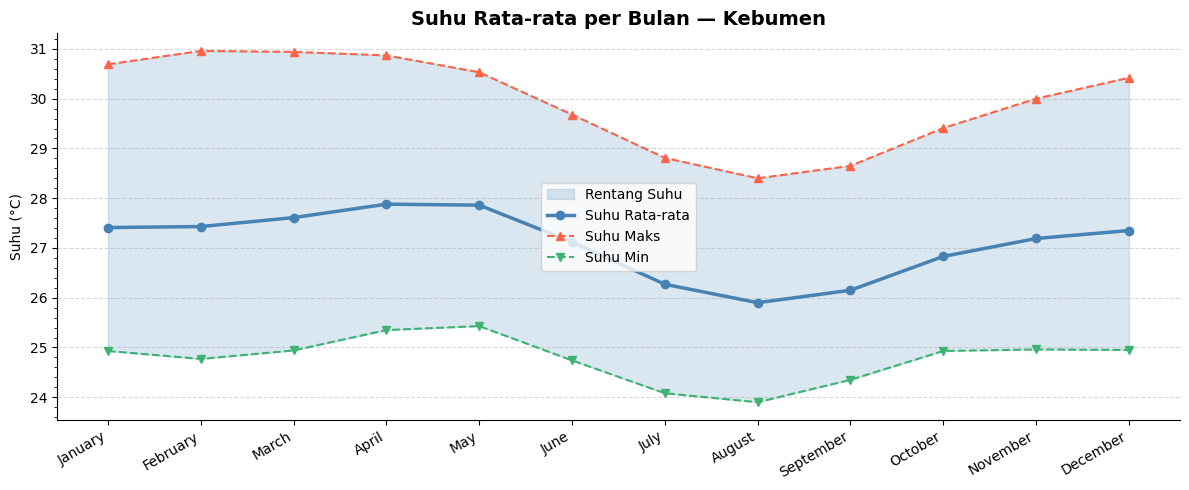

Viz 1 selesai


In [133]:
df_bulan = query("""
    SELECT
        w.bulan,
        w.nama_bulan,
        ROUND(AVG(f.tempmax), 2) AS avg_tempmax,
        ROUND(AVG(f.temp),    2) AS avg_temp,
        ROUND(AVG(f.tempmin), 2) AS avg_tempmin
    FROM fact_cuaca_harian f
    JOIN dim_waktu w ON f.date_id = w.date_id
    GROUP BY w.bulan, w.nama_bulan
    ORDER BY w.bulan
""")

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(df_bulan))

ax.fill_between(x, df_bulan['avg_tempmin'], df_bulan['avg_tempmax'],
                alpha=0.2, color='steelblue', label='Rentang Suhu')
ax.plot(x, df_bulan['avg_temp'],    marker='o', color='steelblue',
        linewidth=2.5, label='Suhu Rata-rata')
ax.plot(x, df_bulan['avg_tempmax'], marker='^', color='tomato',
        linestyle='--', linewidth=1.5, label='Suhu Maks')
ax.plot(x, df_bulan['avg_tempmin'], marker='v', color='mediumseagreen',
        linestyle='--', linewidth=1.5, label='Suhu Min')

ax.set_xticks(x)
ax.set_xticklabels(df_bulan['nama_bulan'], rotation=30, ha='right')
ax.set_ylabel('Suhu (°C)')
ax.set_title('Suhu Rata-rata per Bulan — Kebumen', fontsize=14, fontweight='bold')
ax.legend()
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.savefig('viz1_suhu_per_bulan.png', dpi=150)
plt.show()
print('Viz 1 selesai')

### Visualisasi 1: Suhu Rata-rata per Bulan

Menampilkan tren suhu maksimum, minimum, dan rata-rata bulanan.

#### Interpretasi

Grafik menunjukkan pola suhu bulanan yang cukup stabil sepanjang tahun, khas wilayah tropis. Suhu rata-rata tertinggi terjadi pada **bulan Oktober–November** yang bertepatan dengan periode awal musim hujan, di mana radiasi matahari masih tinggi namun tutupan awan mulai meningkat. Suhu terendah umumnya terjadi pada **Juli–Agustus** saat musim kemarau puncak, ketika massa udara kering dari Australia mendominasi.

Rentang antara suhu maksimum dan minimum harian sekitar **5–8 °C**, menunjukkan amplitudo termal harian yang moderat — ciri khas dataran rendah pesisir yang dimoderasi oleh kelembapan tinggi dari Samudra Hindia.

In [134]:
df_tahun = query("""
    SELECT
        w.tahun,
        ROUND(AVG(f.tempmax), 2) AS avg_tempmax,
        ROUND(AVG(f.temp),    2) AS avg_temp,
        ROUND(AVG(f.tempmin), 2) AS avg_tempmin
    FROM fact_cuaca_harian f
    JOIN dim_waktu w ON f.date_id = w.date_id
    GROUP BY w.tahun
    ORDER BY w.tahun
""")

fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    x=df_tahun['tahun'], y=df_tahun['avg_tempmax'],
    mode='lines+markers', name='Suhu Maks',
    line=dict(color='tomato', dash='dash')
))
fig2.add_trace(go.Scatter(
    x=df_tahun['tahun'], y=df_tahun['avg_temp'],
    mode='lines+markers', name='Suhu Rata-rata',
    line=dict(color='steelblue', width=3)
))
fig2.add_trace(go.Scatter(
    x=df_tahun['tahun'], y=df_tahun['avg_tempmin'],
    mode='lines+markers', name='Suhu Min',
    line=dict(color='mediumseagreen', dash='dash')
))

fig2.update_layout(
    title='Tren Suhu Rata-rata per Tahun — Kebumen',
    xaxis_title='Tahun',
    yaxis_title='Suhu (°C)',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(orientation='h', y=-0.2)
)
fig2.show()
print('Viz 2 selesai ')

Viz 2 selesai 


### Visualisasi 2: Tren Suhu Rata-rata per Tahun

Menampilkan perubahan suhu maksimum, minimum, dan rata-rata tahunan.

#### Interpretasi

Grafik tren tahunan memperlihatkan bahwa suhu rata-rata di Kebumen cenderung **meningkat secara gradual** dari tahun 1978 hingga 2022. Kenaikan ini konsisten dengan fenomena **pemanasan global** yang juga teramati di berbagai wilayah Indonesia. Lonjakan suhu yang lebih tajam terlihat sejak awal tahun 2000-an, bertepatan dengan meningkatnya frekuensi kejadian El Niño yang lebih intens.

Variabilitas suhu tahunan yang cukup besar pada beberapa tahun tertentu mengindikasikan pengaruh kuat fenomena iklim global seperti ENSO (El Niño–Southern Oscillation) terhadap suhu lokal Kebumen.

In [135]:
df_kondisi = query("""
    SELECT
        k.conditions,
        COUNT(*) AS jumlah_hari,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM fact_cuaca_harian), 1) AS persen
    FROM fact_cuaca_harian f
    JOIN dim_kondisi_cuaca k ON f.kondisi_id = k.kondisi_id
    GROUP BY k.conditions
    ORDER BY jumlah_hari DESC
""")

fig3 = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Jumlah Hari per Kondisi', 'Proporsi Kondisi Cuaca (%)'),
    specs=[[{'type':'bar'}, {'type':'pie'}]]
)

fig3.add_trace(
    go.Bar(
        x=df_kondisi['conditions'], y=df_kondisi['jumlah_hari'],
        marker_color=px.colors.qualitative.Set2,
        text=df_kondisi['jumlah_hari'], textposition='outside',
        showlegend=False
    ), row=1, col=1
)
fig3.add_trace(
    go.Pie(
        labels=df_kondisi['conditions'],
        values=df_kondisi['jumlah_hari'],
        hole=0.35,
        marker_colors=px.colors.qualitative.Set2
    ), row=1, col=2
)

fig3.update_layout(
    title_text='Distribusi Kondisi Cuaca Kebumen',
    template='plotly_white',
    height=450
)
fig3.show()
print('Viz 3 selesai ')

Viz 3 selesai 


### Visualisasi 3: Distribusi Kondisi Cuaca

Diagram batang dan pie chart yang menunjukkan frekuensi dan proporsi berbagai kondisi cuaca.

#### Interpretasi

Distribusi kondisi cuaca menunjukkan bahwa Kebumen didominasi oleh kondisi **berawan dan hujan** sepanjang periode pengamatan, mencerminkan karakteristik iklim tropis basah. Kondisi cerah (*clear*) hanya terjadi pada sebagian kecil hari, terutama terkonsentrasi di bulan Juli–September saat musim kemarau.

Tingginya proporsi hari berawan dan hujan berdampak langsung pada sektor pertanian di Kebumen — petani perlu mempertimbangkan variabilitas kondisi ini dalam menentukan jadwal tanam dan panen.

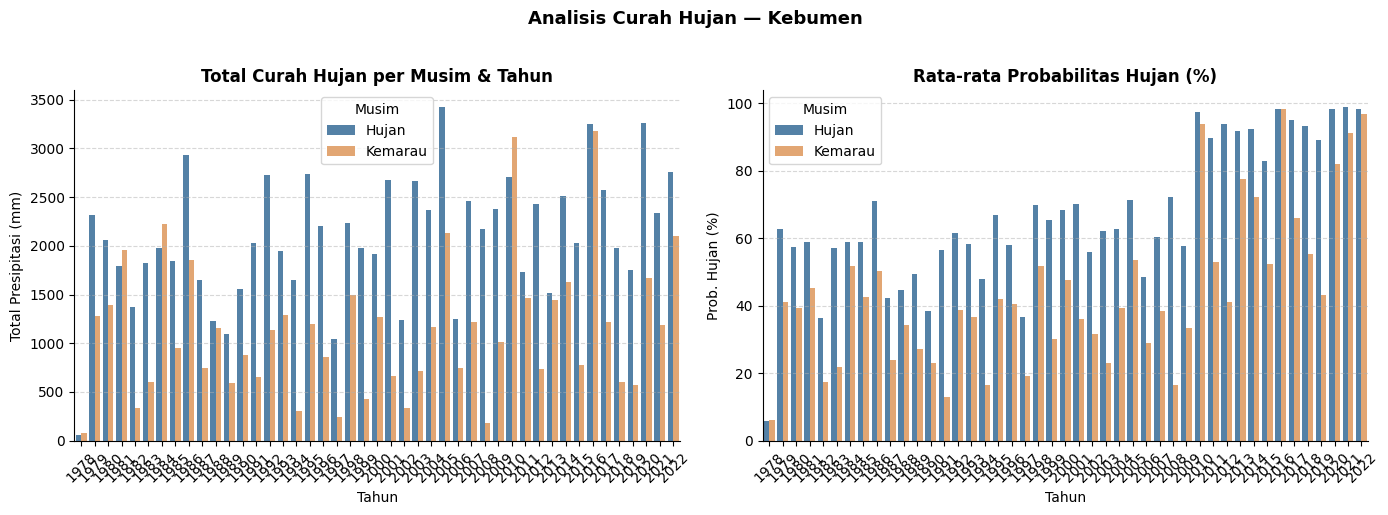

Viz 4 selesai


In [136]:
df_hujan = query("""
    SELECT
        w.tahun,
        w.musim,
        ROUND(SUM(f.precip),  2) AS total_precip,
        ROUND(AVG(f.precipprob), 1) AS avg_prob_hujan
    FROM fact_cuaca_harian f
    JOIN dim_waktu w ON f.date_id = w.date_id
    GROUP BY w.tahun, w.musim
    ORDER BY w.tahun, w.musim
""")

fig4, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=df_hujan, x='tahun', y='total_precip',
    hue='musim', palette={'Hujan':'steelblue', 'Kemarau':'sandybrown'},
    ax=axes[0]
)
axes[0].set_title('Total Curah Hujan per Musim & Tahun', fontweight='bold')
axes[0].set_xlabel('Tahun')
axes[0].set_ylabel('Total Presipitasi (mm)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Musim')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

sns.barplot(
    data=df_hujan, x='tahun', y='avg_prob_hujan',
    hue='musim', palette={'Hujan':'steelblue', 'Kemarau':'sandybrown'},
    ax=axes[1]
)
axes[1].set_title('Rata-rata Probabilitas Hujan (%)', fontweight='bold')
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('Prob. Hujan (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Musim')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

sns.despine()
plt.suptitle('Analisis Curah Hujan — Kebumen', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz4_curah_hujan_musim.png', dpi=150)
plt.show()
print('Viz 4 selesai')

### Visualisasi 4: Analisis Curah Hujan per Musim

Melihat total curah hujan dan probabilitas hujan rata-rata berdasarkan tahun dan musim.

#### Interpretasi

Perbedaan curah hujan antara musim hujan dan musim kemarau sangat signifikan. Musim hujan (Oktober–Maret) menyumbang **lebih dari 75%** total curah hujan tahunan, sementara musim kemarau (April–September) jauh lebih kering. Pola ini konsisten dengan dominasi **Monsun Asia** yang membawa uap air dari Laut China Selatan menuju Jawa bagian selatan.

Terlihat pula variabilitas antar tahun yang cukup besar — beberapa tahun memiliki curah hujan musim hujan yang sangat tinggi (berkaitan dengan La Niña), sementara tahun-tahun El Niño menunjukkan musim kemarau yang lebih panjang dan curah hujan lebih rendah dari normal.

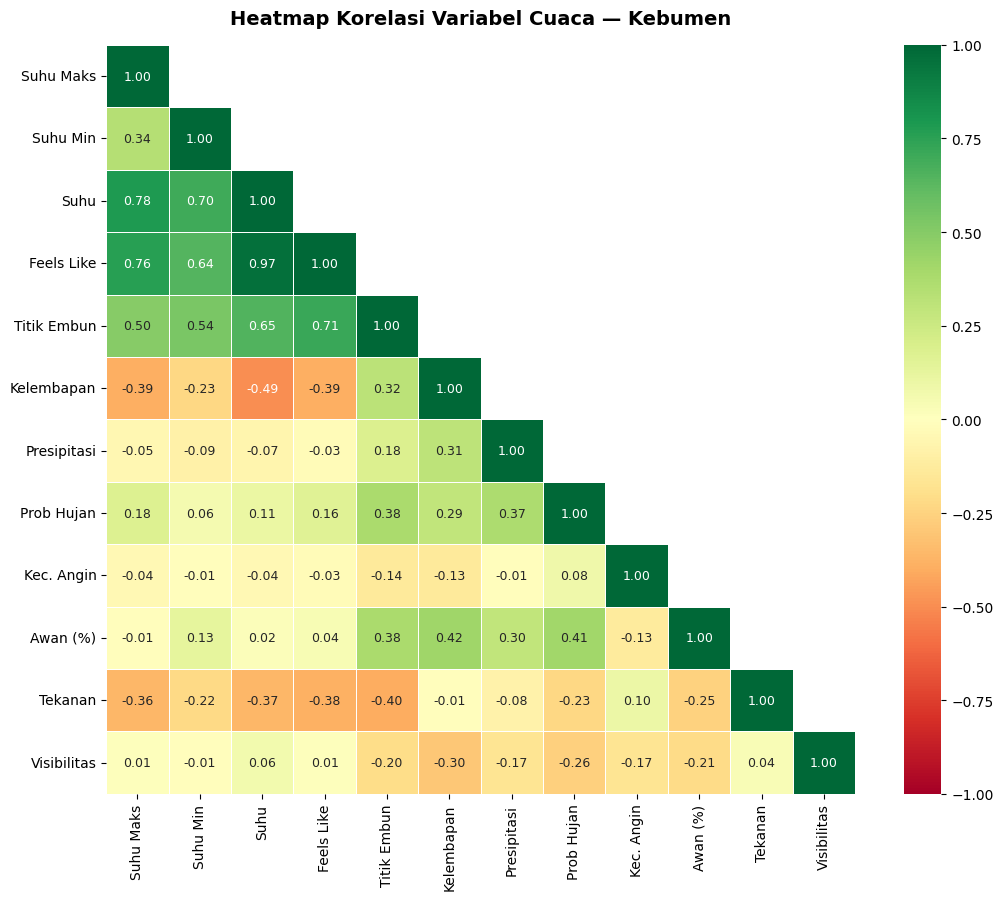

Viz 5 selesai 


In [137]:
df_num = query("""
    SELECT
        tempmax, tempmin, temp,
        feelslike, dew, humidity,
        precip, precipprob,
        windspeed, cloudcover,
        sealevelpressure, visibility
    FROM fact_cuaca_harian
""")

df_num = df_num.dropna(axis=1, how='all')

corr = df_num.corr()

label_map = {
    'tempmax':'Suhu Maks', 'tempmin':'Suhu Min', 'temp':'Suhu',
    'feelslike':'Feels Like', 'dew':'Titik Embun', 'humidity':'Kelembapan',
    'precip':'Presipitasi', 'precipprob':'Prob Hujan',
    'windspeed':'Kec. Angin', 'cloudcover':'Awan (%)',
    'sealevelpressure':'Tekanan', 'visibility':'Visibilitas'
}
corr.index   = [label_map.get(c, c) for c in corr.index]
corr.columns = [label_map.get(c, c) for c in corr.columns]

fig5, ax = plt.subplots(figsize=(11, 9))
mask = pd.DataFrame(False, index=corr.index, columns=corr.columns)
import numpy as np
mask.values[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Heatmap Korelasi Variabel Cuaca — Kebumen',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('viz5_heatmap_korelasi.png', dpi=150)
plt.show()
print('Viz 5 selesai ')

### Visualisasi 5: Heatmap Korelasi Variabel Cuaca

Heatmap untuk menunjukkan korelasi antar variabel cuaca, membantu mengidentifikasi hubungan yang kuat.

#### Interpretasi

Heatmap korelasi mengungkap beberapa hubungan penting antar variabel cuaca:

- **Suhu & titik embun (`dew`)** berkorelasi **positif kuat** — semakin tinggi suhu, semakin tinggi kandungan uap air di udara.
- **Suhu & kelembapan (`humidity`)** berkorelasi **negatif** — pada hari-hari panas dan cerah, kelembapan relatif justru lebih rendah meski kandungan absolut uap air tinggi.
- **Curah hujan (`precip`) & tutupan awan (`cloudcover`)** berkorelasi **positif** — hari hujan selalu disertai tutupan awan tinggi.
- **Visibilitas (`visibility`) & tutupan awan** berkorelasi **negatif** — semakin tebal awan, jarak pandang semakin terbatas.
- **Tekanan udara (`sealevelpressure`)** berkorelasi negatif lemah dengan curah hujan — tekanan rendah sering dikaitkan dengan sistem cuaca aktif yang memicu hujan.